In [1]:
import polars as pl

dataset_created = False

# Expanded required columns: ['gvkey','datadate','fyear','cusip','at','lt','ni','revt','act','lct','re','ebit','sale','mkt']
if dataset_created:
    # Assuming a previously saved CSV matches this schema (ensure all needed columns were included in the clean CSV!)
    df = pl.read_csv('compustat_clean.csv')
else:
    columns_to_read = [
        "gvkey", "datadate", "fyear", "cusip", "at", "lt", "ni", "revt",
        "act", "lct", "re", "ebit", "sale",
    ]
    schema_overrides = {
        "gvkey": pl.Utf8,
        "datadate": pl.Utf8,
        "fyear": pl.Int32,
        "cusip": pl.Utf8,
        "at": pl.Float64,
        "lt": pl.Float64,
        "ni": pl.Float64,
        "revt": pl.Float64,
        "act": pl.Float64,
        "lct": pl.Float64,
        "re": pl.Float64,
        "ebit": pl.Float64,
        "sale": pl.Float64,
        "mkt": pl.Float64,
    }

    df = pl.read_csv(
        "COMPUSTAT_funda_annual.csv",
        columns=columns_to_read,
        schema_overrides=schema_overrides,
        ignore_errors=True
    )

    # Lowercase column names for consistency
    df = df.rename({col: col.lower() for col in df.columns})

    # Optionally: convert datadate column to a date type if needed
    if "datadate" in df.columns:
        df = df.with_columns([
            pl.col("datadate").str.strptime(pl.Date, strict=False).alias("datadate")
        ])

    # Restrict to years 1964–2020
    if "fyear" in df.columns:
        df = df.filter((pl.col("fyear") >= 1964) & (pl.col("fyear") <= 2020))

    df.write_csv("compustat_clean.csv")


In [2]:
df.head()

gvkey,datadate,fyear,cusip,act,at,ebit,lct,lt,ni,re,revt,sale
str,date,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""001000""",1964-12-31,1964,"""000032102""",0.718,1.416,0.074,0.267,0.809,0.052,0.001,2.032,2.032
"""001000""",1965-12-31,1965,"""000032102""",0.725,2.31,-0.242,0.623,1.818,-0.197,-0.196,1.688,1.688
"""001000""",1966-12-31,1966,"""000032102""",1.015,2.43,0.35,0.446,1.596,0.164,-0.031,4.032,4.032
"""001000""",1967-12-31,1967,"""000032102""",1.004,2.456,0.003,0.376,1.712,-0.09,-0.121,3.594,3.594
"""001000""",1968-12-31,1968,"""000032102""",1.865,5.922,0.753,1.248,3.351,0.463,0.558,7.4,7.4


In [3]:
df = df.rename({"fyear": "year"})

In [4]:
# Compute accounting ratios with last-observation-carried-forward imputation
# Columns: ni/at, lt/at (assume 'lt' for total liabilities), nwc/at, re/at, ebit/at, mkt/lt, sale/at

# Ensure data is sorted by 'gvkey'/'cusip' and 'year' for correct imputation
df = df.sort(['gvkey', 'year'])

# Fill-forward financial statement columns groupwise by firm (last available obs imputation)
# Only columns needed for ratios
impute_cols = [
    "ni", "at", "lt", "act", "lct", "re", "ebit", "sale"
]
for col in impute_cols:
    if col in df.columns:
        df = df.with_columns(
            pl.col(col).fill_null(strategy="forward").over("gvkey").alias(col)
        )

# Net working capital = act - lct
if all(col in df.columns for col in ['act', 'lct']):
    df = df.with_columns(
        (pl.col("act") - pl.col("lct")).alias("nwc")
    )

# Accounting ratios
ratio_exprs = []

if "ni" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("ni") / pl.col("at")).otherwise(None)).alias("ni_at")
    )
if "lt" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("lt") / pl.col("at")).otherwise(None)).alias("lt_at")
    )
if "nwc" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("nwc") / pl.col("at")).otherwise(None)).alias("nwc_at")
    )
if "re" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("re") / pl.col("at")).otherwise(None)).alias("re_at")
    )
if "ebit" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("ebit") / pl.col("at")).otherwise(None)).alias("ebit_at")
    )
if "mkt" in df.columns and "lt" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("lt") != 0).then(pl.col("mkt") / pl.col("lt")).otherwise(None)).alias("mkt_lt")
    )
if "sale" in df.columns and "at" in df.columns:
    ratio_exprs.append(
        (pl.when(pl.col("at") != 0).then(pl.col("sale") / pl.col("at")).otherwise(None)).alias("sale_at")
    )

if ratio_exprs:
    df = df.with_columns(ratio_exprs)




In [5]:
df

gvkey,datadate,year,cusip,act,at,ebit,lct,lt,ni,re,revt,sale,nwc,ni_at,lt_at,nwc_at,re_at,ebit_at,sale_at
str,date,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""001000""",1964-12-31,1964,"""000032102""",0.718,1.416,0.074,0.267,0.809,0.052,0.001,2.032,2.032,0.451,0.036723,0.571328,0.318503,0.000706,0.05226,1.435028
"""001000""",1965-12-31,1965,"""000032102""",0.725,2.31,-0.242,0.623,1.818,-0.197,-0.196,1.688,1.688,0.102,-0.085281,0.787013,0.044156,-0.084848,-0.104762,0.730736
"""001000""",1966-12-31,1966,"""000032102""",1.015,2.43,0.35,0.446,1.596,0.164,-0.031,4.032,4.032,0.569,0.06749,0.65679,0.234156,-0.012757,0.144033,1.659259
"""001000""",1967-12-31,1967,"""000032102""",1.004,2.456,0.003,0.376,1.712,-0.09,-0.121,3.594,3.594,0.628,-0.036645,0.697068,0.2557,-0.049267,0.001221,1.463355
"""001000""",1968-12-31,1968,"""000032102""",1.865,5.922,0.753,1.248,3.351,0.463,0.558,7.4,7.4,0.617,0.078183,0.565856,0.104188,0.094225,0.127153,1.249578
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""351038""",2020-12-31,2020,"""74907L300""",0.465,1.378,-1.67,7.985,7.985,-2.095,-6.607,0.0,0.0,-7.52,-1.520319,5.79463,-5.457184,-4.79463,-1.211901,0.0
"""351491""",2019-12-31,2019,"""N47017103""",11570.0,17847.0,650.0,12588.0,14797.0,94.0,null,13408.0,13408.0,-1018.0,0.005267,0.829103,-0.05704,null,0.036421,0.751275
"""351491""",2020-12-31,2020,"""N47017103""",12100.0,18841.0,67.0,13594.0,16025.0,-492.0,null,12549.0,12549.0,-1494.0,-0.026113,0.850539,-0.079295,null,0.003556,0.666047


In [6]:
total_rows = df.height
null_percentages = (
    df.select([
        (pl.col(col).is_null().sum() / total_rows * 100).alias(col)
        for col in df.columns
    ])
    .transpose(include_header=True, header_name="column", column_names=["null_percentage"])
    .sort("null_percentage", descending=True)
)

# Print entire DataFrame (Polars DataFrame) without truncation
print(null_percentages.to_pandas().to_string(index=False))


  column  null_percentage
  nwc_at        31.149944
     nwc        30.927026
     act        30.844307
     lct        28.975635
 ebit_at        17.325576
    ebit        17.093444
   re_at        15.308491
      re        15.059135
    revt        13.992009
 sale_at        13.825971
   ni_at        13.549776
   lt_at        13.477072
    sale        13.315041
      ni        13.308431
      lt        13.250148
      at        12.969146
   cusip         0.018627
   gvkey         0.000000
datadate         0.000000
    year         0.000000


In [7]:
schema = {
    "PERMNO": pl.Int32,    # firm identifier
    "DATE": pl.Utf8,       
    "SICCD": pl.Int32,     # SIC code
    "RET": pl.Float64,    # returns
    "RETX": pl.Float64,    # return (excluding dividends)
    "vwretd": pl.Float64,   # value-weighted return
    "SHROUT": pl.Int64,
    "PRC": pl.Float64
}

crspdf = pl.read_csv(
    "msf_raw_1964To2023.csv",
    schema_overrides=schema,
    try_parse_dates=False,
    null_values=["", "NA", "NaN", "B"],  # treat "B" as missing
    ignore_errors=True,
)

# ==== Parse date column ====
crspdf = crspdf.with_columns(
    pl.col("DATE").str.strptime(pl.Date, format="%Y%m%d", strict=False)
)

# ==== Add year and month columns for convenience ====
crspdf = crspdf.with_columns([
    pl.col("DATE").dt.year().alias("year"),
    pl.col("DATE").dt.month().alias("month")
])

expr = (
    pl.when((pl.col("SICCD") >= 1) & (pl.col("SICCD") <= 999)).then(pl.lit("Agriculture"))
    .when((pl.col("SICCD") >= 1000) & (pl.col("SICCD") <= 1499)).then(pl.lit("Mining"))
    .when((pl.col("SICCD") >= 1500) & (pl.col("SICCD") <= 1799)).then(pl.lit("Construction"))
    .when((pl.col("SICCD") >= 2000) & (pl.col("SICCD") <= 3999)).then(pl.lit("Manufacturing"))
    .when((pl.col("SICCD") >= 4000) & (pl.col("SICCD") <= 4999)).then(pl.lit("Transportation"))
    .when((pl.col("SICCD") >= 5000) & (pl.col("SICCD") <= 5199)).then(pl.lit("Wholesale"))
    .when((pl.col("SICCD") >= 5200) & (pl.col("SICCD") <= 5999)).then(pl.lit("Retail"))
    .when((pl.col("SICCD") >= 6000) & (pl.col("SICCD") <= 6799)).then(pl.lit("Finance"))
    .when((pl.col("SICCD") >= 7000) & (pl.col("SICCD") <= 8999)).then(pl.lit("Services"))
    .when((pl.col("SICCD") >= 9000) & (pl.col("SICCD") <= 9999)).then(pl.lit("PublicAdmin"))
    .otherwise(pl.lit("Other"))
    .alias("industry")
)

crspdf = crspdf.with_columns(expr)

In [8]:
crspdf.head()

DATE,COMNAM,PERMNO,PERMCO,SHRCD,SICCD,CUSIP,BIDLO,ASKHI,PRC,VOL,RET,BID,ASK,SHROUT,RETX,vwretd,year,month,industry
date,str,i32,i64,i64,i32,str,f64,f64,f64,i64,f64,str,str,i64,f64,f64,i32,i8,str
1964-01-31,"""BRITISH AMERICAN TOB LTD""",29874,23656,30,2111,"""11051170""",6.875,-7.6875,-7.375,29,-0.04065,null,null,531,-0.04065,0.02579,1964,1,"""Manufacturing"""
1964-01-31,"""INGERSOLL RAND CO""",12431,20977,11,3563,"""G8994E10""",79.125,86.0,84.0,697,0.033537,null,null,6289,0.02439,0.02579,1964,1,"""Manufacturing"""
1964-01-31,"""EATON MFG CO""",11762,20627,11,3714,"""G2918310""",36.75,42.0,40.25,1709,0.096296,null,null,7206,0.084175,0.02579,1964,1,"""Manufacturing"""
1964-01-31,"""AMERADA PETROLEUM CORP""",15624,22621,10,1311,"""02355510""",70.375,76.5,76.5,1407,0.105925,null,null,12670,0.098743,0.02579,1964,1,"""Mining"""
1964-01-31,"""REALTY EQUITIES CORP NY""",35772,24103,10,6519,"""75609510""",6.0,-6.625,6.5,46,0.007692,null,null,492,0.0,0.02579,1964,1,"""Finance"""


In [9]:
# Much simpler and faster: just group by needed columns and aggregate.
def compute_yearly_crsp_features_simple(df):
    return (
        df
        .with_columns([
            (pl.col("RETX") - pl.col("vwretd")).alias("excess"),
            (pl.col("PRC").abs() * pl.col("SHROUT") * 1000).alias("mktcap_instant")
        ])
        .group_by(["PERMNO", "year", "CUSIP"])
        .agg([
            pl.col("RETX").mean().alias("RETX_mean"),
            pl.col("RETX").std().alias("RETX_vol"),
            pl.col("vwretd").mean().alias("vwretd_mean"),
            pl.col("excess").sum().alias("excess_return"),
            pl.col("mktcap_instant").last().alias("mktcap"),
        ])
    )

crspdf_yearly = compute_yearly_crsp_features_simple(crspdf)
crspdf_yearly.head()


PERMNO,year,CUSIP,RETX_mean,RETX_vol,vwretd_mean,excess_return,mktcap
i32,i32,str,f64,f64,f64,f64,f64
52661,1985,"""58491810""",0.1636905,0.298837,0.041766,0.289281,null
77044,1993,"""84891810""",0.099795,0.2738,0.006744,0.739414,6.565125e6
15903,2019,"""52468L40""",0.014845,0.03023,0.021608,-0.050992,9.0089e8
61322,1997,"""70163010""",0.0317531,0.144675,0.01986,0.333164,6.4792e7
81235,1975,"""92906810""",-0.060424,0.029993,-0.010998,-0.070635,6.89625e6


In [10]:
crspdf_yearly.shape

(375031, 8)

In [11]:
# Prepare both dataframes for merge (cusip6 and year)
df = df.with_columns([
    pl.col("cusip").str.slice(0, 6).alias("cusip6"),
    pl.col("year").cast(pl.Int32),
])
crspdf_yearly = crspdf_yearly.with_columns([
    pl.col("CUSIP").str.slice(0, 6).alias("cusip6"),
    pl.col("year").cast(pl.Int32),
])

# Check for duplicate key pairs in both dataframes before the join
if df.select(["cusip6", "year"]).is_duplicated().any():
    print("Warning: Duplicate (cusip6, year) found in df -- join may produce duplicate rows/")
if crspdf_yearly.select(["cusip6", "year"]).is_duplicated().any():
    print("Warning: Duplicate (cusip6, year) found in crspdf_yearly -- join may produce duplicate rows/")

# Perform a left join to keep all CRSP (market) rows, merging in financial info where possible (loose match on cusip6+year)
merged = crspdf_yearly.join(
    df,
    left_on=["cusip6", "year"],
    right_on=["cusip6", "year"],
    how="left"
)

merged = merged.unique()



In [12]:
merged.head()

PERMNO,year,CUSIP,RETX_mean,RETX_vol,vwretd_mean,excess_return,mktcap,cusip6,gvkey,datadate,cusip,act,at,ebit,lct,lt,ni,re,revt,sale,nwc,ni_at,lt_at,nwc_at,re_at,ebit_at,sale_at
i32,i32,str,f64,f64,f64,f64,f64,str,str,date,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
21135,1982,"""31540510""",0.01943,0.072856,0.050558,-0.047353,1.581445e8,"""315405""","""004622""",1982-12-31,"""315405100""",200.015,348.553,32.443,94.904,183.977,10.277,179.755,595.83,595.83,105.111,0.029485,0.527831,0.301564,0.515718,0.093079,1.709439
13603,2008,"""02888210""",0.007297,0.055792,-0.043976,0.366339,1.5087114e8,"""028882""","""001539""",2008-12-31,"""028882108""",25.934,283.554,29.591,6.687,147.089,19.163,60.029,75.021,74.749,19.247,0.067581,0.518734,0.067878,0.211702,0.104358,0.263615
54199,1981,"""78430510""",0.021113,0.037572,-0.014147,0.146784,2.98025e7,"""784305""","""009324""",1981-12-31,"""784305104""",6.009,124.073,10.706,6.486,76.534,6.683,29.232,38.519,38.519,-0.477,0.053863,0.616847,-0.003845,0.235603,0.086288,0.310454
57314,1978,"""21149010""",0.012241,0.127448,-0.029245,-0.083914,7.5125e7,"""211490""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
15109,2019,"""67075F10""",0.00827,0.037615,0.021608,-0.125619,6.415878e8,"""67075F""","""163844""",2019-12-31,"""67075F105""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [13]:
merged = merged.drop(["datadate"])

In [14]:
merged.shape

(521149, 27)

In [15]:
import polars as pl

# Read bankruptcy data and extract year, month from columns ['PERMNO', 'B_date']
# - Leave B_date as string to avoid SchemaError about "expected String, got date"
bankruptcy = pl.read_csv("bankruptcy_1964_2020.csv", try_parse_dates=False)

if not ("PERMNO" in bankruptcy.columns and "B_date" in bankruptcy.columns):
    raise ValueError(f"Expected columns ['PERMNO', 'B_date'] in: {bankruptcy.columns}")

# Safely parse year and month from the string column B_date, keeping original as string
bankruptcy = bankruptcy.with_columns([
    pl.col("B_date").str.slice(0, 4).cast(pl.Int32).alias("year"),
])

bankruptcy.head()

PERMNO,B_date,year
i64,str,i32
30744,"""1964-03-05""",1964
39001,"""1964-05-22""",1964
29399,"""1964-09-03""",1964
37938,"""1965-03-09""",1965
29532,"""1965-03-10""",1965


In [16]:
# Ensure all join columns are Int32 (i32) before joining
merged = merged.with_columns([
    pl.col("PERMNO").cast(pl.Int32),
    pl.col("year").cast(pl.Int32),
]).join(
    bankruptcy.with_columns([
        pl.col("PERMNO").cast(pl.Int32),
        pl.col("year").cast(pl.Int32),
        pl.lit(1).alias("bankruptcy")
    ]).select(["PERMNO", "year", "bankruptcy"]),
    on=["PERMNO", "year"],
    how="left"
).with_columns([
    pl.col("bankruptcy").fill_null(0).cast(pl.Int8)
])


In [17]:
merged.head()

PERMNO,year,CUSIP,RETX_mean,RETX_vol,vwretd_mean,excess_return,mktcap,cusip6,gvkey,cusip,act,at,ebit,lct,lt,ni,re,revt,sale,nwc,ni_at,lt_at,nwc_at,re_at,ebit_at,sale_at,bankruptcy
i32,i32,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8
21135,1982,"""31540510""",0.01943,0.072856,0.050558,-0.047353,1.581445e8,"""315405""","""004622""","""315405100""",200.015,348.553,32.443,94.904,183.977,10.277,179.755,595.83,595.83,105.111,0.029485,0.527831,0.301564,0.515718,0.093079,1.709439,0
13603,2008,"""02888210""",0.007297,0.055792,-0.043976,0.366339,1.5087114e8,"""028882""","""001539""","""028882108""",25.934,283.554,29.591,6.687,147.089,19.163,60.029,75.021,74.749,19.247,0.067581,0.518734,0.067878,0.211702,0.104358,0.263615,0
54199,1981,"""78430510""",0.021113,0.037572,-0.014147,0.146784,2.98025e7,"""784305""","""009324""","""784305104""",6.009,124.073,10.706,6.486,76.534,6.683,29.232,38.519,38.519,-0.477,0.053863,0.616847,-0.003845,0.235603,0.086288,0.310454,0
57314,1978,"""21149010""",0.012241,0.127448,-0.029245,-0.083914,7.5125e7,"""211490""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0
15109,2019,"""67075F10""",0.00827,0.037615,0.021608,-0.125619,6.415878e8,"""67075F""","""163844""","""67075F105""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0


In [18]:
merged.shape

(521159, 28)

In [19]:
# Calculate percentage of bankruptcies in the merged dataset
total_count = merged.height
bankruptcy_count = merged["bankruptcy"].sum()
percentage_bankruptcy = (bankruptcy_count / total_count) * 100

print(f"Percentage of bankruptcies in the dataset: {percentage_bankruptcy:.2f}%")


Percentage of bankruptcies in the dataset: 0.47%


In [20]:
merged = merged.sort(["PERMNO", "year"])


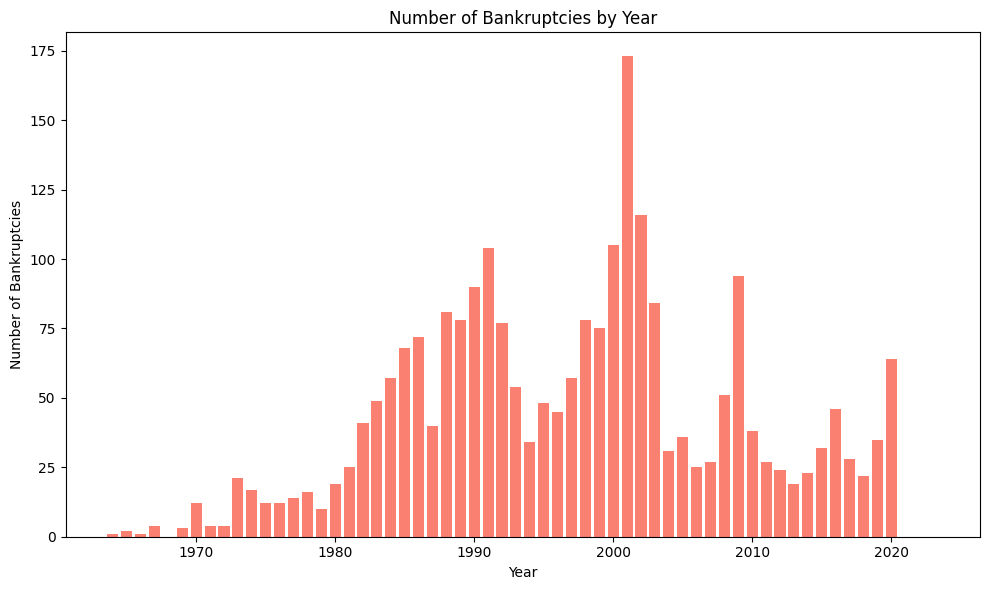

In [21]:
import matplotlib.pyplot as plt

# Group by year and sum the bankruptcy events
bankruptcy_by_year = merged.group_by("year").agg(pl.col("bankruptcy").sum().alias("num_bankruptcies")).sort("year")

# Convert to pandas for plotting
df_bankruptcy_by_year = bankruptcy_by_year.to_pandas()

plt.figure(figsize=(10,6))
plt.bar(df_bankruptcy_by_year["year"], df_bankruptcy_by_year["num_bankruptcies"], color='salmon')
plt.xlabel("Year")
plt.ylabel("Number of Bankruptcies")
plt.title("Number of Bankruptcies by Year")
plt.tight_layout()
plt.show()


In [22]:
merged = merged.with_columns(
    pl.col("bankruptcy")
    .shift(-1)
    .over("PERMNO")
    .alias("bankruptcy_next_year")
)


In [23]:
merged.head()

PERMNO,year,CUSIP,RETX_mean,RETX_vol,vwretd_mean,excess_return,mktcap,cusip6,gvkey,cusip,act,at,ebit,lct,lt,ni,re,revt,sale,nwc,ni_at,lt_at,nwc_at,re_at,ebit_at,sale_at,bankruptcy,bankruptcy_next_year
i32,i32,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8
10000,1986,"""68391610""",-0.148223,0.270361,-0.005718,-0.440391,1.9816e6,"""683916""","""013007""","""683916100""",1.63,2.115,-0.686,1.639,1.697,-0.73,-1.599,1.026,1.026,-0.009,-0.345154,0.802364,-0.004255,-0.756028,-0.32435,0.485106,0,0
10000,1987,"""68391610""",-0.198912,0.192647,0.0336595,-0.408279,null,"""683916""",null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0,null
10001,1986,"""36720410""",-0.009748,0.015598,-0.005489,-0.001658,6.937e6,"""367204""","""012994""","""367204104""",2.359,12.242,1.476,2.259,6.81,0.669,4.439,21.46,21.46,0.1,0.054648,0.556282,0.008169,0.362604,0.120569,1.752982,0,0
10001,1987,"""36720410""",-0.002945,0.038491,0.0322234,-0.17584,5.828e6,"""367204""","""012994""","""367204104""",1.87,11.771,0.624,1.983,6.402,0.312,4.335,16.621,16.621,-0.113,0.026506,0.543879,-0.0096,0.368278,0.053012,1.41203,0,0
10001,1988,"""36720410""",-0.049298,0.029147,0.024021,-0.231518,6.36225e6,"""367204""","""012994""","""367204104""",1.987,11.735,0.984,1.894,6.223,0.564,4.472,16.978,16.978,0.093,0.048061,0.530294,0.007925,0.381082,0.083852,1.446783,0,0


C:\Users\jmani\AppData\Local\Temp\ipykernel_11068\2617549528.py:4: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  firm_years_by_year = merged.group_by("year").count().select(pl.col("year"), pl.col("count").alias("firm_years")).sort("year")


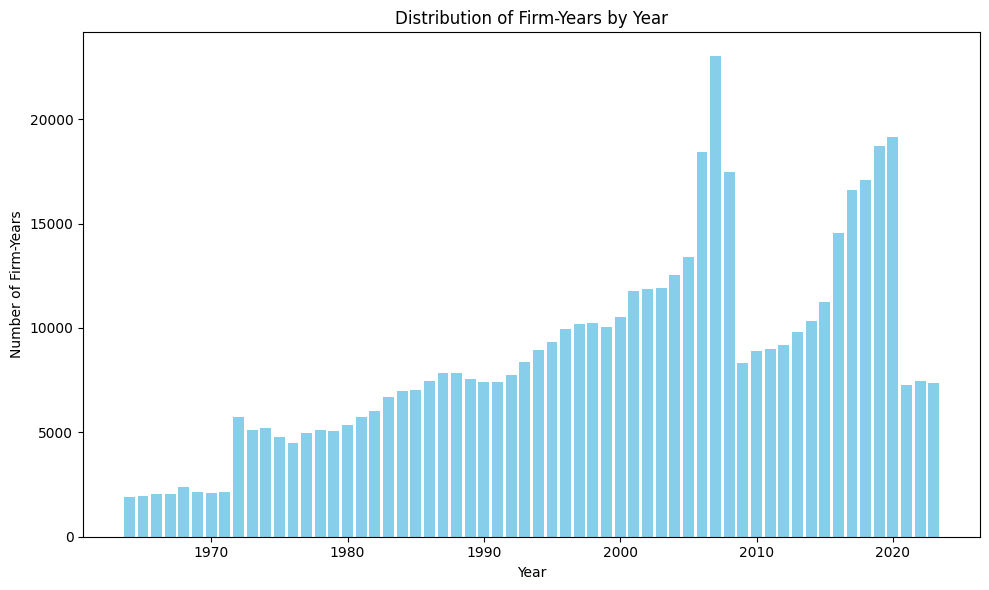

In [24]:
# Distribution of firm years by years
import matplotlib.pyplot as plt

firm_years_by_year = merged.group_by("year").count().select(pl.col("year"), pl.col("count").alias("firm_years")).sort("year")
df_firm_years_by_year = firm_years_by_year.to_pandas()

plt.figure(figsize=(10,6))
plt.bar(df_firm_years_by_year["year"], df_firm_years_by_year["firm_years"], color="skyblue")
plt.xlabel("Year")
plt.ylabel("Number of Firm-Years")
plt.title("Distribution of Firm-Years by Year")
plt.tight_layout()
plt.show()


In [25]:
# Drop rows where either bankruptcy or bankruptcy_next_year are null
merged = merged.filter(
    pl.col("bankruptcy").is_not_null() & pl.col("bankruptcy_next_year").is_not_null()
)

# Impute remaining nulls in each column with the column median (for floats)
# Find all numeric columns except 'bankruptcy' and 'bankruptcy_next_year'
num_cols = [col for col, dtype in merged.schema.items() 
            if dtype in (pl.Float32, pl.Float64) 
            and col not in ["bankruptcy", "bankruptcy_next_year"]]

# Median imputation for numeric columns
impute_exprs = [pl.col(col).fill_null(pl.median(col)).alias(col) for col in num_cols]
merged = merged.with_columns(impute_exprs)


In [26]:
merged.head()

PERMNO,year,CUSIP,RETX_mean,RETX_vol,vwretd_mean,excess_return,mktcap,cusip6,gvkey,cusip,act,at,ebit,lct,lt,ni,re,revt,sale,nwc,ni_at,lt_at,nwc_at,re_at,ebit_at,sale_at,bankruptcy,bankruptcy_next_year
i32,i32,str,f64,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8,i8
10000,1986,"""68391610""",-0.148223,0.270361,-0.005718,-0.440391,1.9816e6,"""683916""","""013007""","""683916100""",1.63,2.115,-0.686,1.639,1.697,-0.73,-1.599,1.026,1.026,-0.009,-0.345154,0.802364,-0.004255,-0.756028,-0.32435,0.485106,0,0
10001,1986,"""36720410""",-0.009748,0.015598,-0.005489,-0.001658,6.937e6,"""367204""","""012994""","""367204104""",2.359,12.242,1.476,2.259,6.81,0.669,4.439,21.46,21.46,0.1,0.054648,0.556282,0.008169,0.362604,0.120569,1.752982,0,0
10001,1987,"""36720410""",-0.002945,0.038491,0.0322234,-0.17584,5.828e6,"""367204""","""012994""","""367204104""",1.87,11.771,0.624,1.983,6.402,0.312,4.335,16.621,16.621,-0.113,0.026506,0.543879,-0.0096,0.368278,0.053012,1.41203,0,0
10001,1988,"""36720410""",-0.049298,0.029147,0.024021,-0.231518,6.36225e6,"""367204""","""012994""","""367204104""",1.987,11.735,0.984,1.894,6.223,0.564,4.472,16.978,16.978,0.093,0.048061,0.530294,0.007925,0.381082,0.083852,1.446783,0,0
10001,1989,"""36720410""",0.015152,0.037794,0.016113,0.041685,1.034775e7,"""367204""","""012994""","""367204104""",3.577,18.565,2.401,2.725,12.244,1.208,5.221,22.91,22.91,0.852,0.065069,0.659521,0.045893,0.281228,0.129329,1.234043,0,0


In [27]:
# Identify float columns and the bankruptcy column
float_cols = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
cols_to_shift = float_cols 
# Filter for columns that still exist in merged (in case some were dropped)
cols_to_shift = [col for col in cols_to_shift if col in merged.columns]

# Generate shifted columns (lagged by 1 year within each PERMNO)
lagged_exprs = [
    pl.col(col).shift(1).over("PERMNO").alias(f"{col}_lag1") for col in cols_to_shift
]

# Add lagged columns
merged = merged.with_columns(lagged_exprs)

# Drop original columns
merged = merged.drop(cols_to_shift)


In [28]:
merged.shape

(487613, 29)

In [29]:
merged.columns

['PERMNO',
 'year',
 'CUSIP',
 'cusip6',
 'gvkey',
 'cusip',
 'bankruptcy',
 'bankruptcy_next_year',
 'RETX_mean_lag1',
 'RETX_vol_lag1',
 'vwretd_mean_lag1',
 'excess_return_lag1',
 'mktcap_lag1',
 'act_lag1',
 'at_lag1',
 'ebit_lag1',
 'lct_lag1',
 'lt_lag1',
 'ni_lag1',
 're_lag1',
 'revt_lag1',
 'sale_lag1',
 'nwc_lag1',
 'ni_at_lag1',
 'lt_at_lag1',
 'nwc_at_lag1',
 're_at_lag1',
 'ebit_at_lag1',
 'sale_at_lag1']

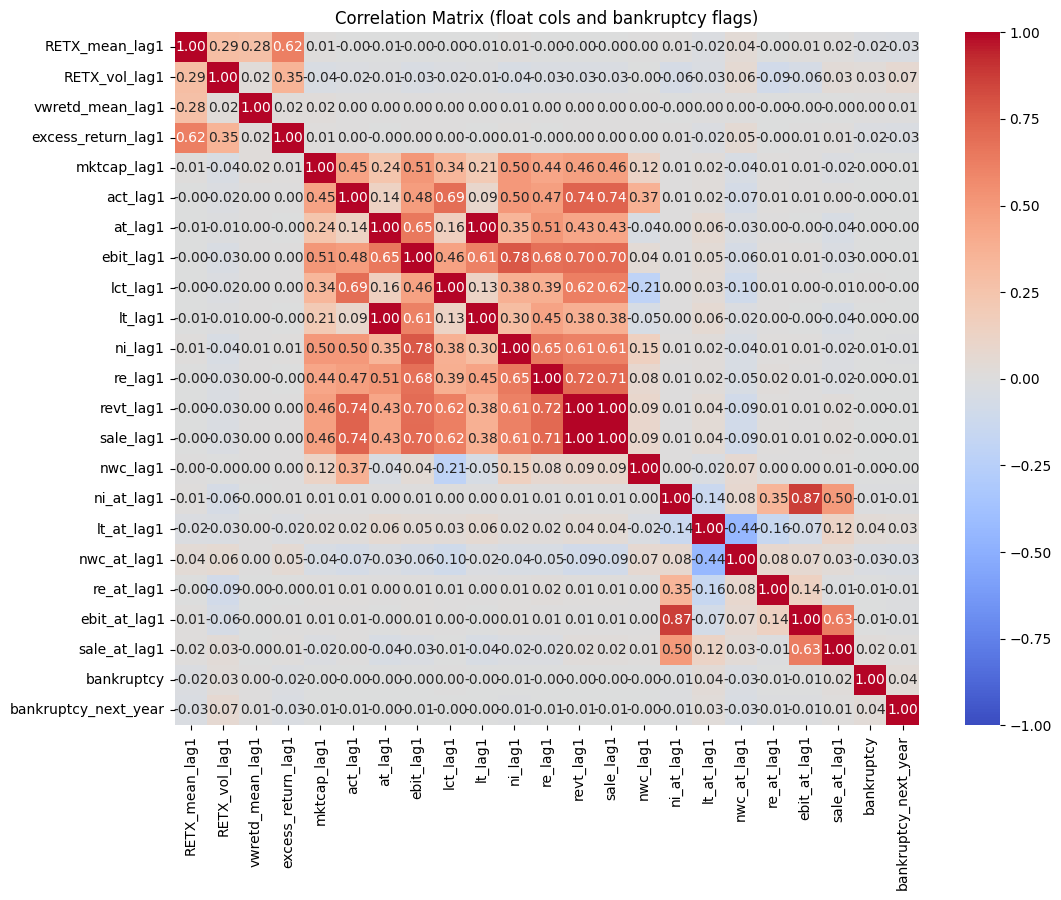

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select float columns and both bankruptcy columns
float_cols = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
cols_to_corr = float_cols + ["bankruptcy", "bankruptcy_next_year"]

# Filter for columns present (avoid issues if any missing)
cols_to_corr = [col for col in cols_to_corr if col in merged.columns]

# Convert to pandas for correlation & plotting
corr_df = merged.select(cols_to_corr).to_pandas()
corr_matrix = corr_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix (float cols and bankruptcy flags)")
plt.show()


In [31]:
# Calculate absolute correlations with all columns
corr_abs = corr_matrix.abs()

# To avoid dropping both columns in a pair, keep track of which ones to drop
to_drop = set()
cols = corr_abs.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if corr_abs.iloc[i, j] > 0.6:
            # Drop the latter column (arbitrary, but deterministic)
            to_drop.add(cols[j])

# Remove selected columns from merged
merged = merged.drop(list(to_drop))


In [32]:
merged = merged.drop_nulls()

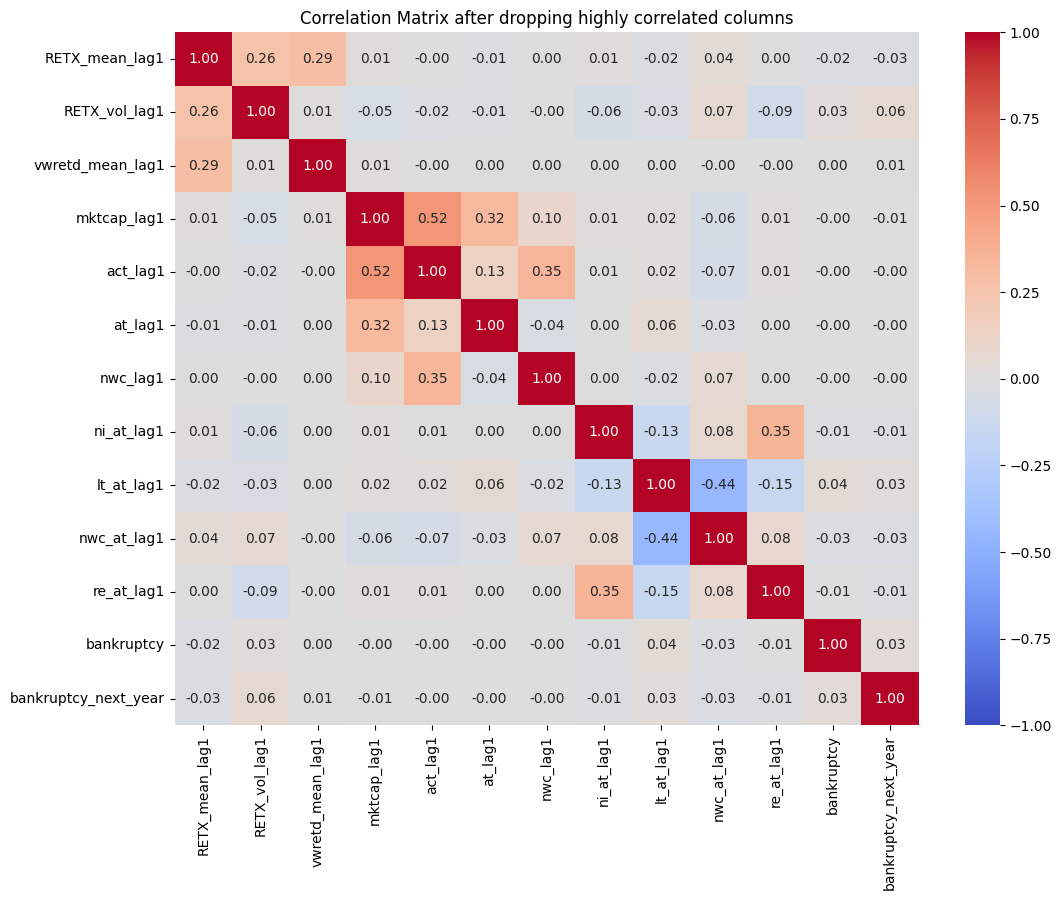

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix of the cleaned/filtered merged DataFrame
float_cols_cleaned = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
cols_to_corr_cleaned = float_cols_cleaned + [col for col in ["bankruptcy", "bankruptcy_next_year"] if col in merged.columns]

# Convert to pandas for correlation & plotting
corr_df_cleaned = merged.select(cols_to_corr_cleaned).to_pandas()
corr_matrix_cleaned = corr_df_cleaned.corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix_cleaned, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Matrix after dropping highly correlated columns")
plt.show()


In [34]:
# Normalize all float columns in merged
float_cols = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
merged = merged.with_columns([
    (pl.col(col) - pl.col(col).mean()) / pl.col(col).std().alias(col)
    for col in float_cols
])


=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.83      0.91     99773
           1       0.02      0.77      0.03       377

    accuracy                           0.83    100150
   macro avg       0.51      0.80      0.47    100150
weighted avg       1.00      0.83      0.91    100150

Accuracy: 0.8346
Precision: 0.0174
Recall: 0.7719
F1 Score: 0.0339
ROC AUC: 0.8609


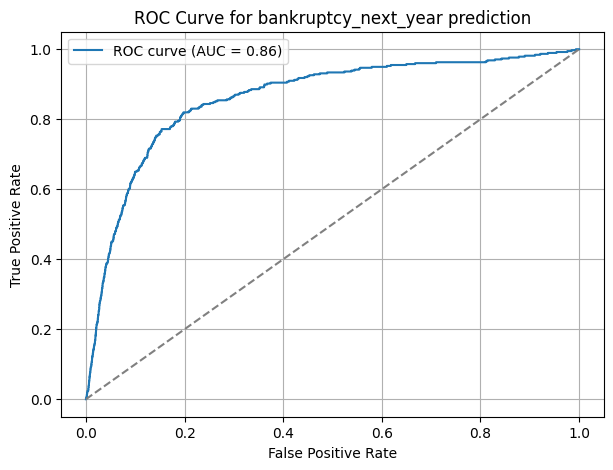

In [35]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import train_test_split

# Feature set: all float columns + 'bankruptcy' (if present)
float_cols_full = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
feature_cols = float_cols_full + [col for col in ["bankruptcy"] if col in merged.columns]
target_col = "bankruptcy_next_year"

# Drop rows where target is null (just in case)
df_classif = merged.select(feature_cols + [target_col]).drop_nulls(target_col).to_pandas()

X = df_classif[feature_cols].copy()
y = df_classif[target_col]

# Split for evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Logistic Regression (with balanced class weights in case of imbalance)
clf = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

# Stats
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for bankruptcy_next_year prediction")
plt.legend(loc='best')
plt.grid(True)
plt.show()


C:\Users\jmani\AppData\Local\Temp\ipykernel_11068\231083020.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X_test_w.groupby("decile")["true"]


=== Bankruptcy Rate by Decile (10=highest risk) ===
  decile  bankruptcy_rate      n
0      1         0.000699  10018
1      2         0.000699  10014
2      3         0.000100  10020
3      4         0.000400  10008
4      5         0.000599  10021
5      6         0.001099  10009
6      7         0.001498  10015
7      8         0.001797  10015
8      9         0.006690  10015
9     10         0.024064  10015


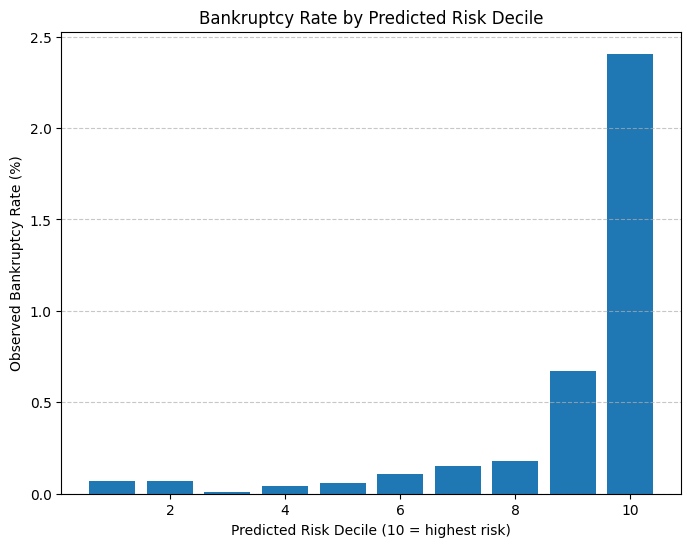

In [37]:
import pandas as pd
# Add decile information to the X_test and predictions from previous classification
X_test_w = X_test.copy()
X_test_w["proba"] = y_proba
X_test_w["true"] = y_test.values

# Assign deciles based on predicted probability (1=lowest risk, 10=highest risk)
X_test_w["decile"] = pd.qcut(X_test_w["proba"], 10, labels=range(1, 11))

# Group by decile, compute bankruptcy rate
decile_summary = (
    X_test_w.groupby("decile")["true"]
    .agg(bankruptcy_rate="mean", n="size")
    .reset_index()
    .sort_values("decile")
)

print("=== Bankruptcy Rate by Decile (10=highest risk) ===")
print(decile_summary)

# Optionally, plot decile bankruptcy rate
plt.figure(figsize=(8,6))
plt.bar(decile_summary["decile"].astype(int), decile_summary["bankruptcy_rate"] * 100)
plt.xlabel("Predicted Risk Decile (10 = highest risk)")
plt.ylabel("Observed Bankruptcy Rate (%)")
plt.title("Bankruptcy Rate by Predicted Risk Decile")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


In-sample n=85773, Out-of-sample n=314824

--- Static Model: Defaults by Decile (1=highest risk) ---
   decile  total_obs  defaults  pct_defaults
0       1      31483       653      2.074135
1       2      31482       159      0.505051
2       3      31483        59      0.187403
3       4      31482        15      0.047646
4       5      31482        18      0.057176
5       6      31483        11      0.034939
6       7      31482        26      0.082587
7       8      31483        27      0.085761
8       9      31482        25      0.079410
9      10      31482        20      0.063528

--- Rolling Model: Defaults by Decile (1=highest risk) ---
   decile  total_obs  defaults  pct_defaults
0       1      31483       670      2.128133
1       2      31482       175      0.555873
2       3      31483        68      0.215990
3       4      31482        21      0.066705
4       5      31482        15      0.047646
5       6      31483        12      0.038116
6       7      31482         

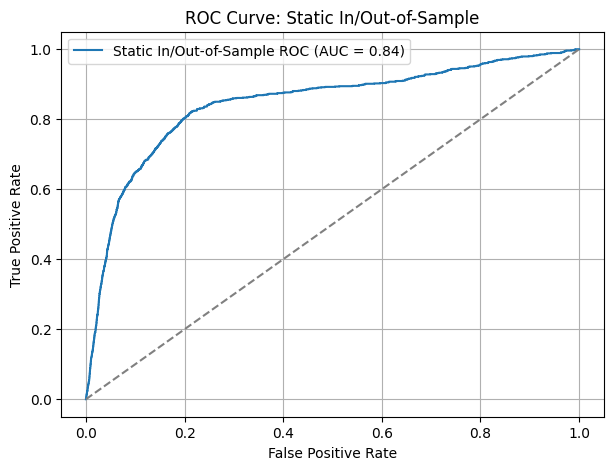

KS Statistic (Static In/Out-of-Sample): 0.6080

--- ROC & KS: Rolling Window Model ---


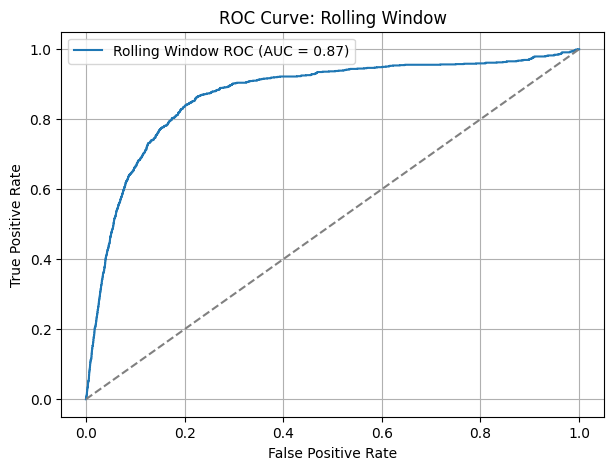

KS Statistic (Rolling Window): 0.6389

--- ROC & KS: Fixed Window Model ---


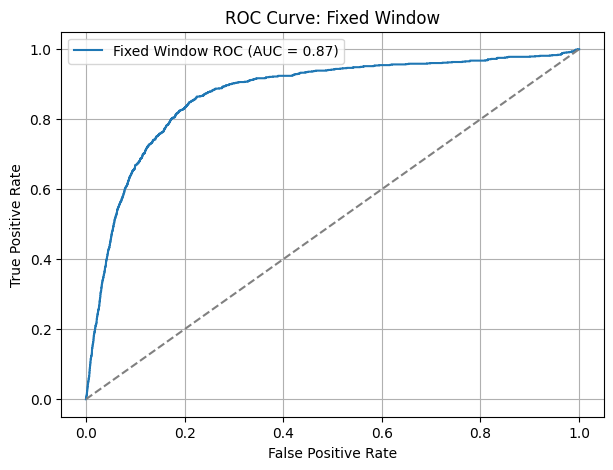

KS Statistic (Fixed Window): 0.6401


In [38]:

import pandas as pd
# 1. Identify feature (estimator) columns and target
float_cols = [name for name in merged.columns if merged.schema[name] in (pl.Float32, pl.Float64)]
feature_cols = float_cols + ([col for col in ["bankruptcy"] if col in merged.columns])
target_col = "bankruptcy_next_year"

# 2. Select relevant columns and drop nulls (do all processing in polars first)
pl_df = merged.select(feature_cols + ["year", target_col])

# 3. Convert to pandas for sklearn
df = pl_df.to_pandas()
X_full = df[feature_cols + ["year"]].copy()
y_full = df[target_col].copy()

# --- 1. Split into in-sample and out-of-sample based on 'year' ---
in_sample_mask = (X_full["year"] >= 1964) & (X_full["year"] <= 1990)
out_sample_mask = (X_full["year"] >= 1991) & (X_full["year"] <= 2020)

X_in_sample = X_full.loc[in_sample_mask].drop(columns="year")
y_in_sample = y_full.loc[in_sample_mask]
X_out_sample = X_full.loc[out_sample_mask].drop(columns="year")
y_out_sample = y_full.loc[out_sample_mask]

print(f"In-sample n={len(X_in_sample)}, Out-of-sample n={len(X_out_sample)}")

# --- 2. Fit static model on in-sample and forecast out-of-sample ---
from sklearn.linear_model import LogisticRegression

clf_static = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight="balanced")
clf_static.fit(X_in_sample, y_in_sample)
oos_proba_static = clf_static.predict_proba(X_out_sample)[:, 1]
oos_pred_static = clf_static.predict(X_out_sample)

# --- 3. Rolling window prediction (expanding window up to year-1 for each test year) ---
rolling_probs = []
rolling_years = []
rolling_actuals = []
for test_year in range(1991, 2021):
    train_idx = X_full["year"] < test_year
    test_idx = X_full["year"] == test_year
    if not test_idx.any():
        continue
    X_train_rolling = X_full.loc[train_idx].drop(columns="year")
    y_train_rolling = y_full.loc[train_idx]
    X_test_rolling = X_full.loc[test_idx].drop(columns="year")
    y_test_rolling = y_full.loc[test_idx]
    clf_rolling = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight="balanced")
    clf_rolling.fit(X_train_rolling, y_train_rolling)
    probas = clf_rolling.predict_proba(X_test_rolling)[:, 1]
    rolling_probs.append(probas)
    rolling_years.append(np.repeat(test_year, len(probas)))
    rolling_actuals.append(y_test_rolling.values)
rolling_probs = np.concatenate(rolling_probs)
rolling_years = np.concatenate(rolling_years)
rolling_actuals = np.concatenate(rolling_actuals)

# --- 4. Fixed window prediction (use most recent window_len years before each test year for train) ---
window_len = 1990 - 1964 + 1
fixed_probs = []
fixed_years = []
fixed_actuals = []
for test_year in range(1991, 2021):
    train_start = test_year - window_len
    train_end = test_year - 1
    train_idx = (X_full["year"] >= train_start) & (X_full["year"] <= train_end)
    test_idx = X_full["year"] == test_year
    if not train_idx.any() or not test_idx.any():
        continue
    X_train = X_full.loc[train_idx].drop(columns="year")
    y_train = y_full.loc[train_idx]
    X_test = X_full.loc[test_idx].drop(columns="year")
    y_test = y_full.loc[test_idx]
    clf_fixed = LogisticRegression(solver='lbfgs', max_iter=2000, class_weight="balanced")
    clf_fixed.fit(X_train, y_train)
    probas = clf_fixed.predict_proba(X_test)[:, 1]
    fixed_probs.append(probas)
    fixed_years.append(np.repeat(test_year, len(probas)))
    fixed_actuals.append(y_test.values)
fixed_probs = np.concatenate(fixed_probs)
fixed_years = np.concatenate(fixed_years)
fixed_actuals = np.concatenate(fixed_actuals)

# --- 5. Rank default probabilities into deciles (1=highest risk, 10=lowest) ---
def add_decile_column(probs, df_index):
    order = np.argsort(-probs)
    deciles = np.zeros(len(probs), dtype=int)
    n = len(probs)
    for i, idx in enumerate(order):
        deciles[idx] = i * 10 // n + 1
    return pd.Series(deciles, index=df_index, name="decile")

# For static model
oos_deciles = add_decile_column(oos_proba_static, X_out_sample.index)
oos_results = pd.DataFrame({
    "proba": oos_proba_static,
    "decile": oos_deciles,
    "actual": y_out_sample
}).reset_index(drop=True)

# For rolling model
rolling_deciles = add_decile_column(rolling_probs, np.arange(len(rolling_probs)))
rolling_results = pd.DataFrame({
    "proba": rolling_probs,
    "decile": rolling_deciles,
    "actual": rolling_actuals
})

# For fixed window model
fixed_deciles = add_decile_column(fixed_probs, np.arange(len(fixed_probs)))
fixed_results = pd.DataFrame({
    "proba": fixed_probs,
    "decile": fixed_deciles,
    "actual": fixed_actuals
})

# --- 6. Compute defaults per decile and percent ---
def default_table(results_df):
    grp = results_df.groupby("decile").agg(
        total_obs=('actual', 'count'),
        defaults=('actual', 'sum')
    ).reset_index().sort_values("decile")
    grp["pct_defaults"] = 100 * grp["defaults"] / grp["total_obs"]
    return grp

print("\n--- Static Model: Defaults by Decile (1=highest risk) ---")
print(default_table(oos_results))
print("\n--- Rolling Model: Defaults by Decile (1=highest risk) ---")
print(default_table(rolling_results))
print("\n--- Fixed Window Model: Defaults by Decile (1=highest risk) ---")
print(default_table(fixed_results))

# --- 7. ROC Curve and AUC/KS Statistics for all three sets ---
from scipy import stats

def plot_roc_ks(y_true, proba, label="Model"):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc = roc_auc_score(y_true, proba)
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"{label} ROC (AUC = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {label}")
    plt.legend()
    plt.grid(True)
    plt.show()
    # KS calculation
    cdf1 = np.sort(proba[y_true == 1])
    cdf0 = np.sort(proba[y_true == 0])
    data_all = np.concatenate([cdf1, cdf0])
    cdf1_vals = np.searchsorted(np.sort(cdf1), data_all, side='right') / len(cdf1)
    cdf0_vals = np.searchsorted(np.sort(cdf0), data_all, side='right') / len(cdf0)
    ks_stat = np.max(np.abs(cdf1_vals - cdf0_vals))
    print(f"KS Statistic ({label}): {ks_stat:.4f}")

print("\n--- ROC & KS: Static Model ---")
plot_roc_ks(y_out_sample, oos_proba_static, label="Static In/Out-of-Sample")
print("\n--- ROC & KS: Rolling Window Model ---")
plot_roc_ks(rolling_actuals, rolling_probs, label="Rolling Window")
print("\n--- ROC & KS: Fixed Window Model ---")
plot_roc_ks(fixed_actuals, fixed_probs, label="Fixed Window")



--- LASSO: #nonzero features ---
5 selected: ['RETX_mean_lag1', 'RETX_vol_lag1', 'ni_at_lag1', 'lt_at_lag1', 'nwc_at_lag1']

--- AUC (1964-1990 train, >1990 test, Post-LASSO Logistic) ---
Post-LASSO: 0.8578
Best LASSO λ (alpha): 0.00131
#nonzero Post-LASSO variables: 5


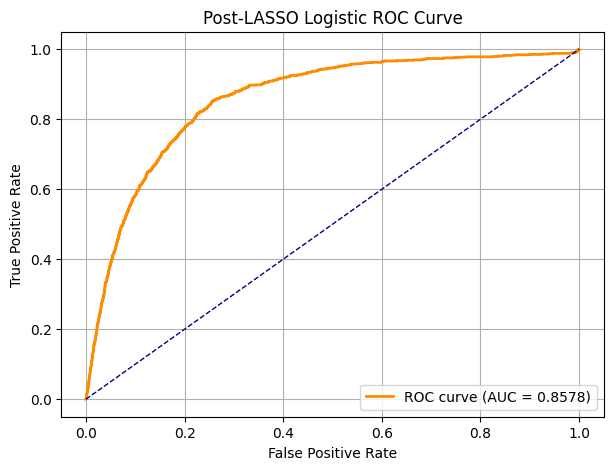

KS Statistic: 0.5953 (at threshold = 0.0053)


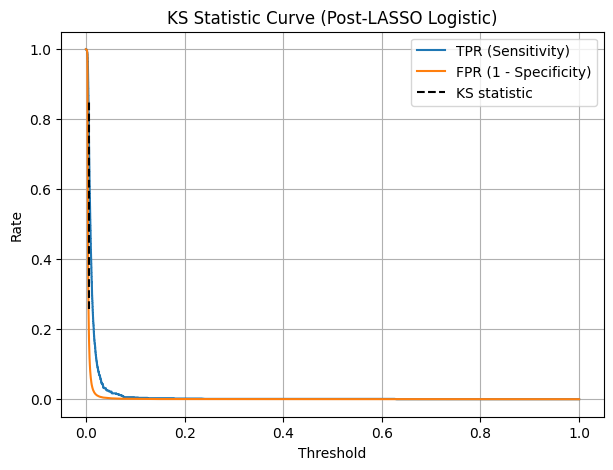


--- Decile Analysis (Post-LASSO Logistic predictions on test set) ---
   decile      n  actual_bankruptcy_rate  mean_pred_proba
0       1  31485                0.000508         0.003004
1       2  31480                0.000191         0.003336
2       3  31482                0.000159         0.003514
3       4  31521                0.000349         0.003720
4       5  31483                0.000508         0.003976
5       6  31461                0.000922         0.004282
6       7  31466                0.001430         0.004674
7       8  31497                0.003270         0.005363
8       9  31466                0.006197         0.006721
9      10  31483                0.018645         0.016641


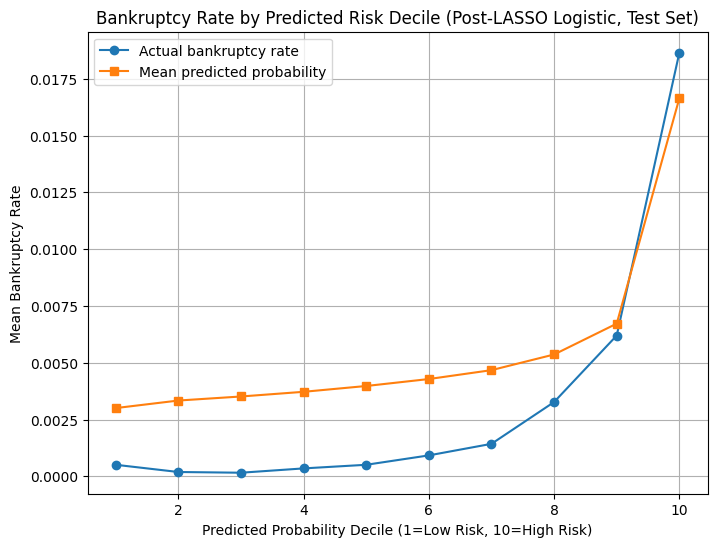

In [39]:
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import polars as pl

# Step 1: Data prep - same as before
ignore_cols = {"PERMNO", "CUSIP", "year", "bankruptcy_next_year"}
feature_cols = [
    c for c in merged.columns
    if (c not in ignore_cols) and (merged.schema[c] in {pl.Float64, pl.Int64, pl.Int32, pl.Float32})
]

years_all = merged["year"].to_numpy()
X_all = merged.select(feature_cols).to_numpy()
y_all = merged["bankruptcy_next_year"].to_numpy()
train_mask = (years_all >= 1964) & (years_all <= 1990)
test_mask = (years_all > 1990)
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

# Standardize features for LASSO (important for regularization)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# --------- LASSO PART ONLY ---------
# Step 2: Use sklearn.linear_model.LassoCV (requires regression formulation)
# To use LassoCV for variable selection, we'll treat y as continuous (even though it's classification)
# Use the optimal alpha (lambda) from in-sample cross-validation

lasso_cv = LassoCV(cv=5, max_iter=3000, random_state=42)
lasso_cv.fit(X_train_std, y_train)

best_lambda_lasso = lasso_cv.alpha_
coef_lasso = lasso_cv.coef_

# Find indices of selected (nonzero) variables
selected_lasso_idx = np.where(coef_lasso != 0)[0]
selected_lasso_vars = [feature_cols[i] for i in selected_lasso_idx]

print("\n--- LASSO: #nonzero features ---")
print(len(selected_lasso_vars), "selected:", selected_lasso_vars)

# Step 4: Post-LASSO Logistic regression on selected features
if selected_lasso_vars:
    X_train_lasso = merged.select(selected_lasso_vars).to_numpy()[train_mask]
    X_test_lasso = merged.select(selected_lasso_vars).to_numpy()[test_mask]
    scaler_lasso = StandardScaler()
    X_train_lasso_std = scaler_lasso.fit_transform(X_train_lasso)
    X_test_lasso_std = scaler_lasso.transform(X_test_lasso)
    post_lasso_logit = LogisticRegression(penalty=None, max_iter=3000, solver="lbfgs")
    post_lasso_logit.fit(X_train_lasso_std, y_train)
    proba_lasso_post = post_lasso_logit.predict_proba(X_test_lasso_std)[:, 1]
else:
    # fallback: no features selected
    proba_lasso_post = np.full(len(y_test), y_train.mean())

results_lasso_post = pd.DataFrame({
    "year": years_all[test_mask],
    "actual": y_test,
    "pred_proba": proba_lasso_post
})

# --- Report performance ---
print("\n--- AUC (1964-1990 train, >1990 test, Post-LASSO Logistic) ---")
print(f"Post-LASSO: {roc_auc_score(results_lasso_post['actual'], results_lasso_post['pred_proba']):.4f}")
print(f"Best LASSO λ (alpha): {best_lambda_lasso:.5f}")
print(f"#nonzero Post-LASSO variables: {len(selected_lasso_vars)}")

# Plotting ROC curve and calculating/reporting KS statistics for post-LASSO Logistic

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curve
fpr, tpr, thresholds = roc_curve(results_lasso_post["actual"], results_lasso_post["pred_proba"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Post-LASSO Logistic ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# KS statistic: max difference between TPR and FPR
ks_stat = np.max(np.abs(tpr - fpr))
ks_idx = np.argmax(np.abs(tpr - fpr))
ks_threshold = thresholds[ks_idx]

print(f"KS Statistic: {ks_stat:.4f} (at threshold = {ks_threshold:.4f})")

# Plot KS curve
plt.figure(figsize=(7, 5))
plt.plot(thresholds, tpr, label="TPR (Sensitivity)")
plt.plot(thresholds, fpr, label="FPR (1 - Specificity)")
plt.plot([ks_threshold, ks_threshold], [fpr[ks_idx], tpr[ks_idx]], "k--", label="KS statistic")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Curve (Post-LASSO Logistic)")
plt.legend()
plt.grid(True)
plt.show()
# Calculate deciles of predicted probabilities for test set
results_lasso_post["decile"] = pd.qcut(results_lasso_post["pred_proba"], 10, labels=False, duplicates="drop") + 1  # 1=lowest risk, 10=highest

# Calculate mean actual bankruptcy and mean predicted probability in each decile
decile_summary = results_lasso_post.groupby("decile").agg(
    n=("actual", "size"),
    actual_bankruptcy_rate=("actual", "mean"),
    mean_pred_proba=("pred_proba", "mean")
).reset_index()

print("\n--- Decile Analysis (Post-LASSO Logistic predictions on test set) ---")
print(decile_summary)

# Plot decile analysis: Actual vs predicted by risk decile
plt.figure(figsize=(8, 6))
plt.plot(decile_summary["decile"], decile_summary["actual_bankruptcy_rate"], marker="o", label="Actual bankruptcy rate")
plt.plot(decile_summary["decile"], decile_summary["mean_pred_proba"], marker="s", label="Mean predicted probability")
plt.xlabel("Predicted Probability Decile (1=Low Risk, 10=High Risk)")
plt.ylabel("Mean Bankruptcy Rate")
plt.title("Bankruptcy Rate by Predicted Risk Decile (Post-LASSO Logistic, Test Set)")
plt.legend()
plt.grid(True)
plt.show()





--- AUC (1964-1990 train, >1990 test, Ridge Logistic Regression) ---
Ridge: 0.8677
Best Ridge λ (alpha): 10000.000000


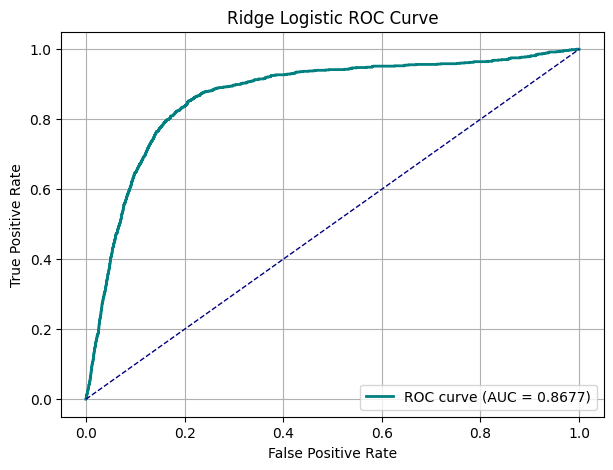

KS Statistic (Ridge): 0.6443 (at threshold = 0.0058)


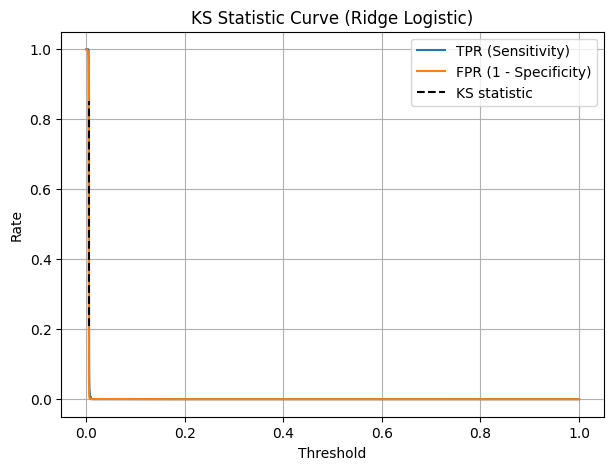


--- Ridge Decile Table ---
   decile  mean_pred_prob  frac_bankrupt  count
0       1        0.005162       0.000667  31483
1       2        0.005594       0.000476  31487
2       3        0.005636       0.000254  31495
3       4        0.005658       0.000159  31470
4       5        0.005681       0.000318  31492
5       6        0.005709       0.000477  31467
6       7        0.005743       0.000985  31483
7       8        0.005794       0.001969  31482
8       9        0.005890       0.006194  31482
9      10        0.006500       0.020678  31483


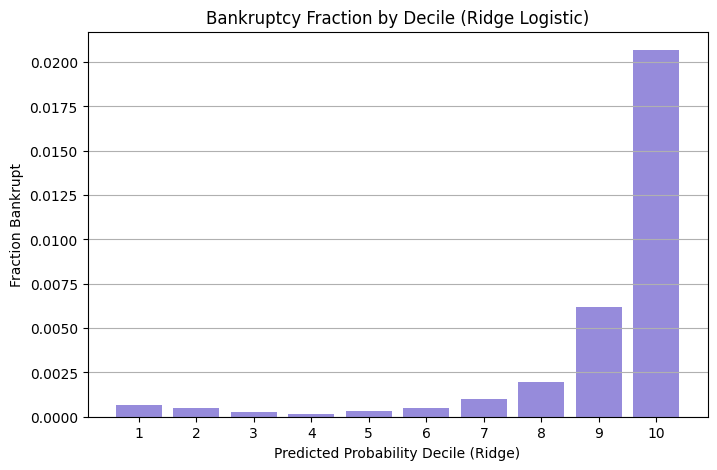

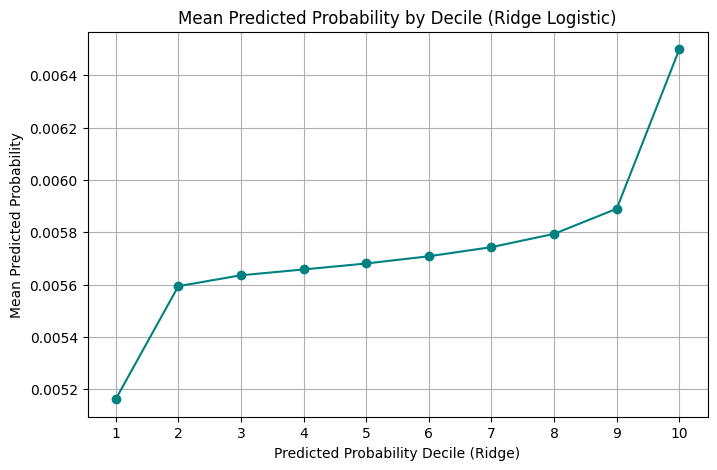

In [40]:
# --- Ridge Regression for Bankruptcy Prediction (using merged df, 1964-1990 train, >1990 test) ---

from sklearn.linear_model import LogisticRegressionCV

# Use the data prep as in the earlier context: select features using ignore_cols and merged dtypes
ignore_cols = {"PERMNO", "CUSIP", "year", "bankruptcy_next_year"}
feature_cols = [
    c for c in merged.columns
    if (c not in ignore_cols) and (merged.schema[c] in {pl.Float64, pl.Int64, pl.Int32, pl.Float32})
]

years_all = merged["year"].to_numpy()
X_all = merged.select(feature_cols).to_numpy()
# For Ridge, label is 'bankruptcy', not 'bankruptcy_next_year'
y_all = merged["bankruptcy_next_year"].to_numpy()

train_mask = (years_all >= 1964) & (years_all <= 1990)
test_mask = (years_all > 1990)
X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_test = X_all[test_mask]
y_test = y_all[test_mask]

# Standardize features for Ridge
scaler_ridge = StandardScaler()
X_train_ridge = scaler_ridge.fit_transform(X_train)
X_test_ridge = scaler_ridge.transform(X_test)

# Fit Ridge Logistic Regression (L2), with cross-validation to find best C (inverse of alpha)
ridge_cv = LogisticRegressionCV(
    Cs=20,                # finer grid of regularization strengths
    penalty='l2',
    solver='lbfgs',
    scoring='roc_auc',
    cv=5,
    max_iter=2000,
    n_jobs=-1,
    refit=True,
    random_state=1,
)
ridge_cv.fit(X_train_ridge, y_train)

best_lambda_ridge = 1 / ridge_cv.C_[0]

print("\n--- AUC (1964-1990 train, >1990 test, Ridge Logistic Regression) ---")
ridge_preds = ridge_cv.predict_proba(X_test_ridge)[:, 1]
print(f"Ridge: {roc_auc_score(y_test, ridge_preds):.4f}")
print(f"Best Ridge λ (alpha): {best_lambda_ridge:.6f}")

# ROC curve
fpr_ridge, tpr_ridge, thresholds_ridge = roc_curve(y_test, ridge_preds)
roc_auc_ridge = auc(fpr_ridge, tpr_ridge)

plt.figure(figsize=(7, 5))
plt.plot(fpr_ridge, tpr_ridge, color="teal", lw=2, label=f"ROC curve (AUC = {roc_auc_ridge:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Ridge Logistic ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# KS statistic for Ridge
ks_stat_ridge = np.max(np.abs(tpr_ridge - fpr_ridge))
ks_idx_ridge = np.argmax(np.abs(tpr_ridge - fpr_ridge))
ks_threshold_ridge = thresholds_ridge[ks_idx_ridge]

print(f"KS Statistic (Ridge): {ks_stat_ridge:.4f} (at threshold = {ks_threshold_ridge:.4f})")

# Plot KS curve
plt.figure(figsize=(7, 5))
plt.plot(thresholds_ridge, tpr_ridge, label="TPR (Sensitivity)")
plt.plot(thresholds_ridge, fpr_ridge, label="FPR (1 - Specificity)")
plt.plot([ks_threshold_ridge, ks_threshold_ridge], [fpr_ridge[ks_idx_ridge], tpr_ridge[ks_idx_ridge]], "k--", label="KS statistic")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Curve (Ridge Logistic)")
plt.legend()
plt.grid(True)
plt.show()

# --- Decile Analysis for Ridge Logistic Regression predictions ---
# Bin the predicted probabilities into deciles and compute statistics

import pandas as pd

# Create a DataFrame for analysis
ridge_decile_df = pd.DataFrame({
    'y_true': y_test,
    'pred_prob': ridge_preds
}).reset_index(drop=True)

# Assign decile (1 = lowest, 10 = highest)
ridge_decile_df['decile'] = pd.qcut(ridge_decile_df['pred_prob'], 10, labels=False, duplicates='drop') + 1  # deciles 1-10

# Aggregate by decile: mean predicted probability, fraction of bankruptcies, count
ridge_deciles = ridge_decile_df.groupby('decile').agg(
    mean_pred_prob=('pred_prob', 'mean'),
    frac_bankrupt=('y_true', 'mean'),
    count=('y_true', 'size')
).reset_index()

print("\n--- Ridge Decile Table ---")
print(ridge_deciles)

# Plot the decile distribution of actual bankruptcies
plt.figure(figsize=(8, 5))
plt.bar(ridge_deciles['decile'], ridge_deciles['frac_bankrupt'], color="slateblue", alpha=0.7)
plt.xlabel("Predicted Probability Decile (Ridge)")
plt.ylabel("Fraction Bankrupt")
plt.title("Bankruptcy Fraction by Decile (Ridge Logistic)")
plt.xticks(ridge_deciles['decile'])
plt.grid(axis='y')
plt.show()

# Also show mean predicted probability in each decile
plt.figure(figsize=(8, 5))
plt.plot(ridge_deciles['decile'], ridge_deciles['mean_pred_prob'], marker="o", color="teal")
plt.xlabel("Predicted Probability Decile (Ridge)")
plt.ylabel("Mean Predicted Probability")
plt.title("Mean Predicted Probability by Decile (Ridge Logistic)")
plt.xticks(ridge_deciles['decile'])
plt.grid(True)
plt.show()




--- AUC (1964-1990 train, >1990 test, KNN Classifier) ---
KNN (n_neighbors=5): 0.5448


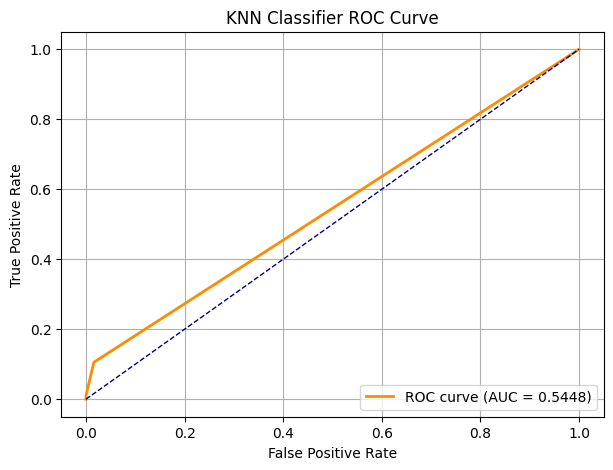

KS Statistic (KNN): 0.0895 (at threshold = 0.2000)


In [41]:
# --- Simpler KNN Classifier (no grid search) ---
from sklearn.neighbors import KNeighborsClassifier

print("\n--- AUC (1964-1990 train, >1990 test, KNN Classifier) ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_ridge, y_train)

knn_preds = knn.predict_proba(X_test_ridge)[:, 1]
auc_knn = roc_auc_score(y_test, knn_preds)
print(f"KNN (n_neighbors=5): {auc_knn:.4f}")

# ROC curve for KNN
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, knn_preds)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr_knn, tpr_knn, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_knn:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN Classifier ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# KS statistic for KNN
ks_stat_knn = np.max(np.abs(tpr_knn - fpr_knn))
ks_idx_knn = np.argmax(np.abs(tpr_knn - fpr_knn))
ks_threshold_knn = thresholds_knn[ks_idx_knn]
print(f"KS Statistic (KNN): {ks_stat_knn:.4f} (at threshold = {ks_threshold_knn:.4f})")



Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best params (Random Forest): {'max_depth': 5, 'n_estimators': 100}
Best CV ROC-AUC: 0.8382
Random Forest AUC (test set): 0.8753


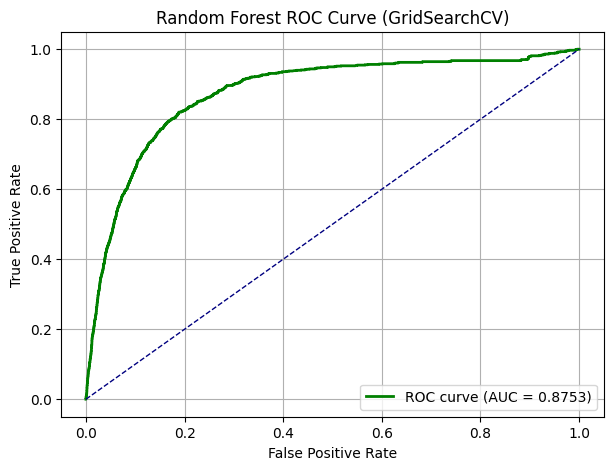

KS Statistic (RF): 0.6319 (at threshold = 0.0079)


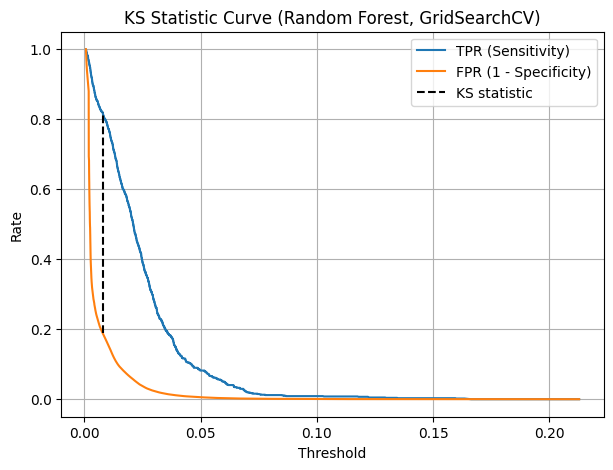

In [ ]:
# Quick GridSearch for Random Forest + ROC/KS

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Very simple grid: n_estimators and max_depth
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search, optimize for ROC-AUC
grid = GridSearchCV(
    rf_base, 
    param_grid, 
    scoring="roc_auc", 
    cv=3, 
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_ridge, y_train)

print("Best params (Random Forest):", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

# Predict/proba using best estimator
rf_best = grid.best_estimator_
rf_preds = rf_best.predict_proba(X_test_ridge)[:, 1]
auc_rf = roc_auc_score(y_test, rf_preds)
print(f"Random Forest AUC (test set): {auc_rf:.4f}")

# ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_preds)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, color="green", lw=2, label=f"ROC curve (AUC = {roc_auc_rf:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve (GridSearchCV)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# KS statistic and curve for Random Forest
ks_stat_rf = np.max(np.abs(tpr_rf - fpr_rf))
ks_idx_rf = np.argmax(np.abs(tpr_rf - fpr_rf))
ks_threshold_rf = thresholds_rf[ks_idx_rf]
print(f"KS Statistic (RF): {ks_stat_rf:.4f} (at threshold = {ks_threshold_rf:.4f})")

plt.figure(figsize=(7, 5))
plt.plot(thresholds_rf, tpr_rf, label="TPR (Sensitivity)")
plt.plot(thresholds_rf, fpr_rf, label="FPR (1 - Specificity)")
plt.plot([ks_threshold_rf, ks_threshold_rf], [fpr_rf[ks_idx_rf], tpr_rf[ks_idx_rf]], "k--", label="KS statistic")
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("KS Statistic Curve (Random Forest, GridSearchCV)")
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
# Minimal RSF: Only fit default model, no hyperparameter search

import numpy as np
from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# durations fixed at 1
duration_train = np.ones(X_train_ridge.shape[0])
event_train = y_train.values.astype(bool) if hasattr(y_train, "values") else y_train.astype(bool)
y_train_surv = Surv.from_arrays(event=event_train, time=duration_train)

# Use RSF with minimal settings for speed (just default, smallest reasonable n_estimators)
rsf = RandomSurvivalForest(
    n_estimators=10,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    verbose=0
)
rsf.fit(X_train_ridge, y_train_surv)

risk_scores = rsf.predict(X_test_ridge)
threshold = np.median(risk_scores)
y_pred_rsf = (risk_scores >= threshold).astype(int)
y_true = y_test.astype(int)

accuracy_rsf = accuracy_score(y_true, y_pred_rsf)
miss_class_rsf = 1 - accuracy_rsf
print("RSF accuracy:", accuracy_rsf)
print("Miss classification rate:", miss_class_rsf)
print("Report:\n", classification_report(y_true, y_pred_rsf, digits=4))
print("CM:\n", confusion_matrix(y_true, y_pred_rsf))


In [41]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Set up a parameter grid for number of boosting rounds (n_estimators)
param_grid = {
    'n_estimators': [25, 50, 100, 150, 200]
}

# Fit model using GridSearchCV to find the optimal n_estimators using out-of-sample (validation) data
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0)
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='accuracy', 
    cv=5, 
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_ridge, y_train)

print("Best n_estimators:", grid_search.best_params_['n_estimators'])
print("Best cross-validation accuracy:", grid_search.best_score_)

# Final model with best number of boosting rounds
best_n = grid_search.best_params_['n_estimators']
xgb_final = XGBClassifier(n_estimators=best_n, use_label_encoder=False, eval_metric='logloss', random_state=0)
xgb_final.fit(X_train_ridge, y_train)

# Out-of-sample prediction
y_pred_xgb = xgb_final.predict(X_test_ridge)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_xgb)
miss_clf_rate = 1 - accuracy
print("XGBoost out-of-sample accuracy:", accuracy)
print("Miss classification rate:", miss_clf_rate)
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

# Miss classification rate per label/class
cm = confusion_matrix(y_test, y_pred_xgb)
labels = range(cm.shape[0])
miss_per_label = {}
for i in labels:
    total = cm[i, :].sum()
    correct = cm[i, i]
    if total > 0:
        miss_per_label[i] = 1 - (correct / total)
    else:
        miss_per_label[i] = None  # undefined if label not in y_test

for label, rate in miss_per_label.items():
    print(f"Miss classification rate for label {label}: {rate}")


Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\jmani\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:58:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best n_estimators: 25
Best cross-validation accuracy: 0.9941939786161242


c:\Users\jmani\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:59:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost out-of-sample accuracy: 0.9967188016161411
Miss classification rate: 0.0032811983838588743
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    313811
           1       0.12      0.00      0.01      1013

    accuracy                           1.00    314824
   macro avg       0.56      0.50      0.50    314824
weighted avg       0.99      1.00      1.00    314824

Miss classification rate for label 0: 7.329252320664725e-05
Miss classification rate for label 1: 0.9970384995064165


In [42]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

# Use a much smaller search to save time
lgb_base = LGBMClassifier(random_state=0)
param_grid_lgb = {'n_estimators': [50, 100]}  # Much smaller grid

grid_search_lgb = GridSearchCV(
    estimator=lgb_base,
    param_grid=param_grid_lgb,
    scoring='accuracy',
    cv=3,         # Reduce cross-validation folds for speed
    n_jobs=-1,
    verbose=1
)
grid_search_lgb.fit(X_train_ridge, y_train)

print("Best n_estimators (LightGBM):", grid_search_lgb.best_params_['n_estimators'])
print("Best cross-validation accuracy (LightGBM):", grid_search_lgb.best_score_)

# Final LightGBM model with the best number of boosting rounds
best_n_lgb = grid_search_lgb.best_params_['n_estimators']
lgb_final = LGBMClassifier(n_estimators=best_n_lgb, random_state=0)
lgb_final.fit(X_train_ridge, y_train)

# Out-of-sample prediction for LightGBM
y_pred_lgb = lgb_final.predict(X_test_ridge)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
miss_clf_rate_lgb = 1 - accuracy_lgb
print("LightGBM out-of-sample accuracy:", accuracy_lgb)
print("Miss classification rate (LightGBM):", miss_clf_rate_lgb)
print("Classification Report (LightGBM):\n", classification_report(y_test, y_pred_lgb))

# Miss classification rate per label/class (LightGBM)
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
labels_lgb = range(cm_lgb.shape[0])
miss_per_label_lgb = {}
for i in labels_lgb:
    total = cm_lgb[i, :].sum()
    correct = cm_lgb[i, i]
    if total > 0:
        miss_per_label_lgb[i] = 1 - (correct / total)
    else:
        miss_per_label_lgb[i] = None  # undefined if label not in y_test

for label, rate in miss_per_label_lgb.items():
    print(f"LightGBM miss classification rate for label {label}: {rate}")


Fitting 3 folds for each of 2 candidates, totalling 6 fits
[LightGBM] [Info] Number of positive: 493, number of negative: 85280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.125891 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 85773, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.005748 -> initscore=-5.153186
[LightGBM] [Info] Start training from score -5.153186
Best n_estimators (LightGBM): 100
Best cross-validation accuracy (LightGBM): 0.9937392885873177
[LightGBM] [Info] Number of positive: 493, number of negative: 85280
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 85773, number of used features

c:\Users\jmani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM out-of-sample accuracy: 0.995286255177496
Miss classification rate (LightGBM): 0.0047137448225039735
Classification Report (LightGBM):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    313811
           1       0.04      0.02      0.03      1013

    accuracy                           1.00    314824
   macro avg       0.52      0.51      0.51    314824
weighted avg       0.99      1.00      0.99    314824

LightGBM miss classification rate for label 0: 0.0015646360388896774
LightGBM miss classification rate for label 1: 0.9802566633761106
